# 03. EDA — 수요·운항 안정성 탐색

### 단계 연결

- 이전 작업(02): 원문을 보존하면서 시간·문자열을 표준화하고, 국내선·국제선 판별 근거가 포함된 분석용 뷰를 만들었다.
- 이번 작업(03): 국제선 수요 패턴과 운항 상태·시간 관계를 탐색하고, 04에 적용할 지연·분모·자정 보정 규칙을 선택한다.

02의 분석용 뷰를 사용해 국제선 출발 수요와 인천·김포 출발편의 상태·시간 관계를 탐색한다. 02의 국제선 여부(`is_international = TRUE`)를 기본 분석 범위로 사용하며, 미확정 목적지의 추가 편입 여부만 후속 검토한다. 지연 정의·분모·자정 보정은 민감도 결과를 바탕으로 04에 적용할 방향을 정리한다.


## 0. 연결 설정

In [1]:
from pathlib import Path
import os
import re


import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from IPython.display import display

PLOTLY_TEMPLATE = 'plotly_white'

def _format_chart_period(value) -> str:
    text_value = str(value).strip().removesuffix('.0')
    if re.fullmatch(r'\d{6}', text_value):
        return f'{text_value[:4]}-{text_value[4:6]}'
    if re.fullmatch(r'\d{4}', text_value):
        return text_value
    try:
        return pd.to_datetime(value).strftime('%Y-%m')
    except (TypeError, ValueError):
        return text_value

def chart_title(title: str, periods) -> str:
    period_values = pd.Series(list(periods)).dropna().map(_format_chart_period)
    if period_values.empty:
        return title
    start_period = period_values.min()
    end_period = period_values.max()
    period_text = start_period if start_period == end_period else f'{start_period} ~ {end_period}'
    return f'{title}<br><sup>데이터 범위: {period_text}</sup>'
pd.set_option('display.max_columns', None)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

load_dotenv(ROOT / '.env')
SQL_FILE = ROOT / 'sql' / '03_eda.sql'

db_config = {
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT', '3306')),
    'database': os.getenv('DB_NAME'),
    'username': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
}
missing = [key for key in ['host', 'database', 'username', 'password'] if not db_config[key]]
if missing:
    raise ValueError(f'.env의 DB 설정이 비어 있음: {missing}')

engine = create_engine(URL.create('mysql+pymysql', **db_config), pool_pre_ping=True, future=True)

def load_named_queries(path: Path) -> dict[str, str]:
    sql_text = path.read_text(encoding='utf-8')
    matches = list(re.finditer(r'^-- name: ([a-z0-9_]+)\s*$', sql_text, flags=re.MULTILINE))
    return {
        match.group(1): sql_text[match.end(): matches[index + 1].start() if index + 1 < len(matches) else len(sql_text)].strip().rstrip(';')
        for index, match in enumerate(matches)
    }

SQL = load_named_queries(SQL_FILE)

# SQL 컬럼명은 유지하고 노트북에 표시할 때만 한국어로 바꾼다.
COLUMN_LABELS = {
    'dataset': '데이터셋',
    'first_period_ym': '시작 연월',
    'last_period_ym': '종료 연월',
    'month_count': '월 수',
    'rows_count': '행 수',
    'period_ym': '연월',
    'incheon_gimpo_passengers': '인천·김포 여객 수',
    'national_passengers': '전국 여객 수',
    'incheon_gimpo_passenger_share': '인천·김포 여객 비중',
    'incheon_gimpo_operations': '인천·김포 운항편 수',
    'national_operations': '전국 운항편 수',
    'incheon_gimpo_operation_share': '인천·김포 운항 비중',
    'airport_name_raw': '출발공항 원문',
    'service_type_raw': '서비스 구분 원문',
    'status_raw': '상태 원문',
    'flight_rows': '출발편 수',
    'airport_total_rows': '공항 전체 행 수',
    'share_within_airport': '공항 내 비중',
    'reference_evidence': '참조 근거',
    'destination_group_count': '목적지 그룹 수',
    'flight_row_share': '출발편 비중',
    'destination_raw': '목적지 원문',
    'destination_std': '목적지 표준값',
    'domestic_raw_values': '국내 공항 참조값',
    'international_raw_values': '국제선 노선 참조값',
    'passengers': '여객 수',
    'operations': '운항편 수',
    'passengers_per_operation': '편당 여객 수',
    'operating_year': '연도',
    'passenger_yoy_rate': '여객 전년 대비 증감률',
    'operation_yoy_rate': '운항 전년 대비 증감률',
    'calendar_month': '월',
    'observed_years': '관측 연도 수',
    'avg_passengers': '평균 여객 수',
    'min_passengers': '최소 여객 수',
    'max_passengers': '최대 여객 수',
    'avg_passenger_seasonal_index': '평균 여객 계절 지수',
    'avg_operations': '평균 운항편 수',
    'min_operations': '최소 운항편 수',
    'max_operations': '최대 운항편 수',
    'avg_operation_seasonal_index': '평균 운항 계절 지수',
    'observed_months': '관측 월 수',
    'passenger_share': '여객 비중',
    'region_raw': '지역 원문',
    'country_raw': '국가 원문',
    'destination_airport_raw': '목적지 공항 원문',
    'origin_airport_raw': '출발공항 원문',
    'airline_name_raw': '항공사 원문',
    'passenger_rows': '여객편 수',
    'time_calculable_rows': '시간 계산 가능 편 수',
    'time_calculable_rate': '시간 계산 가능 비율',
    'min_raw_gap_minutes': '최소 원시 시간차(분)',
    'max_raw_gap_minutes': '최대 원시 시간차(분)',
    'avg_raw_gap_minutes': '평균 원시 시간차(분)',
    'negative_gap_rows': '음수 시간차 편 수',
    'zero_gap_rows': '0분 편 수',
    'gap_1_to_14_rows': '1~14분 편 수',
    'gap_15_to_29_rows': '15~29분 편 수',
    'gap_at_least_15_rows': '15분 이상 편 수',
    'gap_at_least_30_rows': '30분 이상 편 수',
    'scheduled_estimated_rows': '계획·예상 계산 가능 편 수',
    'avg_estimated_minus_scheduled': '평균 예상-계획 시간차(분)',
    'estimated_before_scheduled_rows': '예상시각이 계획보다 이른 편 수',
    'estimated_actual_rows': '예상·실제 계산 가능 편 수',
    'avg_actual_minus_estimated': '평균 실제-예상 시간차(분)',
    'actual_before_estimated_rows': '실제시각이 예상보다 이른 편 수',
    'status_operated_rows': '상태상 운항 편 수',
    'status_operated_time_calculable_rows': '상태상 운항·시간 계산 가능 편 수',
    'not_cancelled_rows': '취소 외 편 수',
    'cancelled_rows': '취소 편 수',
    'diverted_rows': '회항 편 수',
    'status_unknown_rows': '상태 미상 편 수',
    'threshold_minutes': '임계값(분)',
    'candidate_denominator_rows': '분모 후보 편 수',
    'status_delayed_rows': '상태 지연 편 수',
    'threshold_delayed_rows': '임계값 지연 편 수',
    'threshold_delayed_rate': '임계값 지연 비율',
    'both_delayed_rows': '두 기준 모두 지연 편 수',
    'status_only_rows': '상태만 지연 편 수',
    'threshold_only_rows': '임계값만 지연 편 수',
    'negative_gap_band': '음수 시간차 구간',
    'min_scheduled_hour': '최소 계획 시',
    'max_scheduled_hour': '최대 계획 시',
    'adjustment_rule': '보정 후보',
    'candidate_rows': '후보 편 수',
    'adjusted_rows': '보정 적용 편 수',
    'remaining_negative_rows': '보정 후 음수 편 수',
    'avg_scenario_gap_minutes': '보정 후 평균 시간차(분)',
    'reason_filled_rows': '사유 입력 편 수',
    'reason_filled_rate': '사유 입력률',
    'delay_reason_std': '지연사유 표준값',
    'is_reason_operational_outcome': '운항결과 사유 여부',
    'raw_reason_values': '지연사유 원문값',
    'reason_rows': '사유 편 수',
    'delayed_status_rows': '지연 상태 편 수',
    'departed_status_rows': '출발 상태 편 수',
    'cancelled_status_rows': '취소 상태 편 수',
    'diverted_status_rows': '회항 상태 편 수',
    'delay_reason_raw': '지연사유 원문',
    'declared_ontime_rows': '정시 신고 편 수',
    'median_actual_minus_scheduled': '실제-계획 중앙 시간차(분)',
    'avg_actual_minus_scheduled': '실제-계획 평균 시간차(분)',
    'gap_at_least_15_rate': '15분 이상 시간차 비율',
}

def query(name: str) -> pd.DataFrame:
    result = pd.read_sql(text(SQL[name]), engine)
    return result.rename(columns=COLUMN_LABELS)

with engine.connect() as connection:
    connection.execute(text('SELECT 1'))

print(f"Connected to MySQL database: {db_config['database']}")

Connected to MySQL database: korea_outbound_travel


## 1. 데이터 범위·국제선 판별 근거

In [2]:
# 03 입력 뷰의 기간·행 범위를 확인한다.
eda_source_coverage_df = query('eda_source_coverage')
display(eda_source_coverage_df)
EDA_PERIODS = [
    eda_source_coverage_df['시작 연월'].min(),
    eda_source_coverage_df['종료 연월'].max(),
]

,데이터셋,시작 연월,종료 연월,월 수,행 수
0,v_airline_monthly,202301,202512,36,3843
1,v_airport_monthly,202301,202512,36,265
2,v_country_monthly,202301,202512,36,2047
3,v_flight_analysis,202301,202512,36,793865
4,v_route_monthly,202301,202512,36,9634


In [3]:
# 전국 국제선 출발 여객에서 인천·김포 로그가 대표하는 범위를 확인한다.
display(query('incheon_gimpo_demand_coverage'))

,연월,인천·김포 여객 수,전국 여객 수,인천·김포 여객 비중
0,202301,2066716.0,2403433.0,0.8599
1,202302,1878805.0,2212589.0,0.8491
2,202303,1957201.0,2256529.0,0.8674
3,202304,2114505.0,2412373.0,0.8765
4,202305,2304567.0,2622755.0,0.8787
5,202306,2425847.0,2782311.0,0.8719
6,202307,2814194.0,3269172.0,0.8608
7,202308,2785291.0,3247603.0,0.8576
8,202309,2623290.0,3048940.0,0.8604
9,202310,2705056.0,3171814.0,0.8528


In [4]:
# 전국 국제선 출발 운항에서 인천·김포 로그가 대표하는 범위를 확인한다.
display(query('incheon_gimpo_operation_coverage'))

,연월,인천·김포 운항편 수,전국 운항편 수,인천·김포 운항 비중
0,202301,11687.0,13632.0,0.8573
1,202302,11005.0,12937.0,0.8507
2,202303,12475.0,14407.0,0.8659
3,202304,13310.0,15231.0,0.8739
4,202305,14748.0,16781.0,0.8789
5,202306,14610.0,16757.0,0.8719
6,202307,16044.0,18718.0,0.8571
7,202308,16318.0,19138.0,0.8526
8,202309,15757.0,18503.0,0.8516
9,202310,16555.0,19565.0,0.8462


In [5]:
# 공항별 전체 로그·여객편·국내·국제·미확정 여객편 범위를 확인한다.
flight_scope_coverage_df = query('flight_scope_coverage').rename(columns={
    'all_departure_log_rows': '전체 출발 로그 수',
    'domestic_passenger_rows': '국내선 여객편 수',
    'international_passenger_rows': '국제선 여객편 수',
    'unresolved_passenger_rows': '미확정 여객편 수',
    'reference_conflict_passenger_rows': '참조 충돌 여객편 수',
    'international_passenger_share': '국제선 여객편 비중',
})
display(flight_scope_coverage_df)


,출발공항 원문,전체 출발 로그 수,여객편 수,국내선 여객편 수,국제선 여객편 수,미확정 여객편 수,참조 충돌 여객편 수,국제선 여객편 비중
0,김포,199127,198986.0,168083.0,30899.0,4.0,0.0,0.1553
1,인천,594738,511769.0,6047.0,504543.0,1179.0,0.0,0.9859


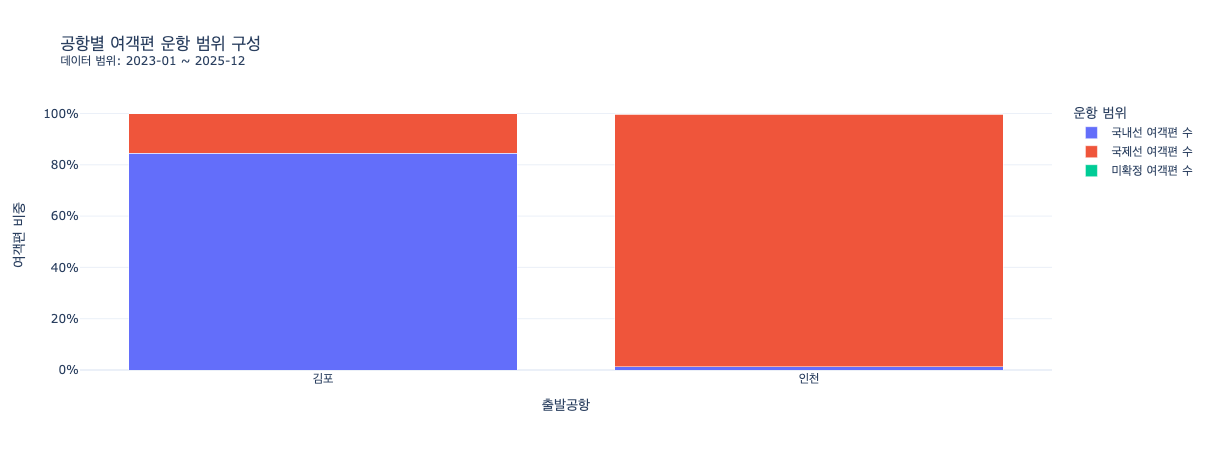

In [6]:
# 차트: 공항별 여객편의 국내선·국제선·미확정 구성을 비교한다.
scope_long = flight_scope_coverage_df[
    ['출발공항 원문', '국내선 여객편 수', '국제선 여객편 수', '미확정 여객편 수']
].melt(
    id_vars='출발공항 원문', var_name='운항 범위', value_name='여객편 수'
)
scope_long['여객편 비중'] = scope_long['여객편 수'] / scope_long.groupby(
    '출발공항 원문'
)['여객편 수'].transform('sum')

fig = px.bar(
    scope_long,
    x='출발공항 원문',
    y='여객편 비중',
    color='운항 범위',
    barmode='stack',
    title=chart_title('공항별 여객편 운항 범위 구성', EDA_PERIODS),
    labels={'출발공항 원문': '출발공항', '여객편 비중': '여객편 비중'},
    template=PLOTLY_TEMPLATE,
)
fig.update_yaxes(tickformat='.0%')
fig.update_layout(height=450, legend_title_text='운항 범위')
fig.show(config={'displaylogo': False})


In [7]:
# 국내선·국제선 판별 전에 출발 로그의 서비스·상태·범위 구성을 확인한다.
display(query('flight_scope_profile').rename(columns={
    'flight_scope_std': '운항 범위',
}))

,출발공항 원문,서비스 구분 원문,상태 원문,운항 범위,출발편 수,공항 전체 행 수,공항 내 비중
0,김포,여객,출발,domestic,128006,199127.0,0.6428
1,김포,여객,지연,domestic,38113,199127.0,0.1914
2,김포,여객,출발,international,28477,199127.0,0.1430
3,김포,여객,지연,international,2232,199127.0,0.0112
4,김포,여객,취소,domestic,1352,199127.0,0.0068
...,...,...,...,...,...,...,...
61,인천,여객,취소,unresolved,2,594738.0,0.0000
62,인천,기타,취소,domestic,1,594738.0,0.0000
63,인천,기타,회항,international,1,594738.0,0.0000
64,인천,화물,지연,domestic,1,594738.0,0.0000


In [8]:
# 국내 공항 참조와 국제선 노선 목적지 참조의 대조 결과를 요약한다.
display(query('international_reference_evidence_summary').rename(columns={
    'flight_scope_std': '운항 범위',
}))

,운항 범위,목적지 그룹 수,출발편 수,출발편 비중
0,international,205,535442.0,0.7533
1,domestic,13,174130.0,0.2450
2,unresolved,14,1183.0,0.0017


In [9]:
# 미확정·참조 충돌 목적지를 상위 일부만 자르지 않고 검토한다.
reference_review = query('international_reference_review_destinations').rename(columns={
    'destination_canonical_std': '목적지 대표 표준값',
    'flight_scope_std': '운항 범위',
    'scope_reference_source': '범위 판별 근거',
})
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(reference_review)

,목적지 원문,목적지 표준값,목적지 대표 표준값,운항 범위,범위 판별 근거,출발편 수
0,카트비,카트비,카트비,unresolved,no_reference_match,1018
1,오르도스 에진 호로,오르도스에진호로,오르도스에진호로,unresolved,no_reference_match,67
2,황산,황산,황산,unresolved,no_reference_match,46
3,다통,다통,다통,unresolved,no_reference_match,27
4,None,None,None,unresolved,blank_destination,6
5,조지아,조지아,조지아,unresolved,no_reference_match,6
6,푸바이,푸바이,푸바이,unresolved,no_reference_match,4
7,휴스턴,휴스턴,휴스턴,unresolved,no_reference_match,3
8,베를린,베를린,베를린,unresolved,no_reference_match,1
9,셀레타,셀레타,셀레타,unresolved,no_reference_match,1


### 국제선 판별 해석

- 공식 국내 공항 목록, 국제선 노선 목적지 목록, 검토된 표기 별칭을 적용해 운항 범위(`flight_scope_std`)를 국내선(`domestic`)·국제선(`international`)·미확정(`unresolved`)·참조 충돌(`reference_conflict`)로 구분한다.
- 여객편 710,755건 중 국제선은 535,442건(75.33%), 국내선은 174,130건(24.50%), 미확정은 1,183건(0.17%)이며 참조 충돌은 없다.
- 공항별 국제선 여객편 비중은 김포 15.53%, 인천 98.59%로 출발 로그의 공항별 구성 차이가 크다.
- 미확정 목적지 14개 조합 중 카트비가 1,018건으로 대부분을 차지한다. 미확정 조합은 외부 참조로 추가 확인한 뒤 국제선 편입 여부를 결정한다.
- 04의 기본 범위는 여객편 여부와 국제선 여부가 모두 참인 행(`is_passenger = TRUE AND is_international = TRUE`)으로 두고, 확인되지 않은 미확정·참조 충돌 편은 임의로 포함하지 않는다.

## 2. 국제선 출발 수요 패턴

In [10]:
# 월별 여객·운항 추이를 확인한다. 표는 앞 5행만 표시하고 차트는 전체 기간을 사용한다.
monthly_demand_trend_df = query('monthly_demand_trend')
display(monthly_demand_trend_df.head(5))


,연월,여객 수,운항편 수,편당 여객 수
0,202301,2403433.0,13632.0,176.31
1,202302,2212589.0,12937.0,171.03
2,202303,2256529.0,14407.0,156.63
3,202304,2412373.0,15231.0,158.39
4,202305,2622755.0,16781.0,156.29


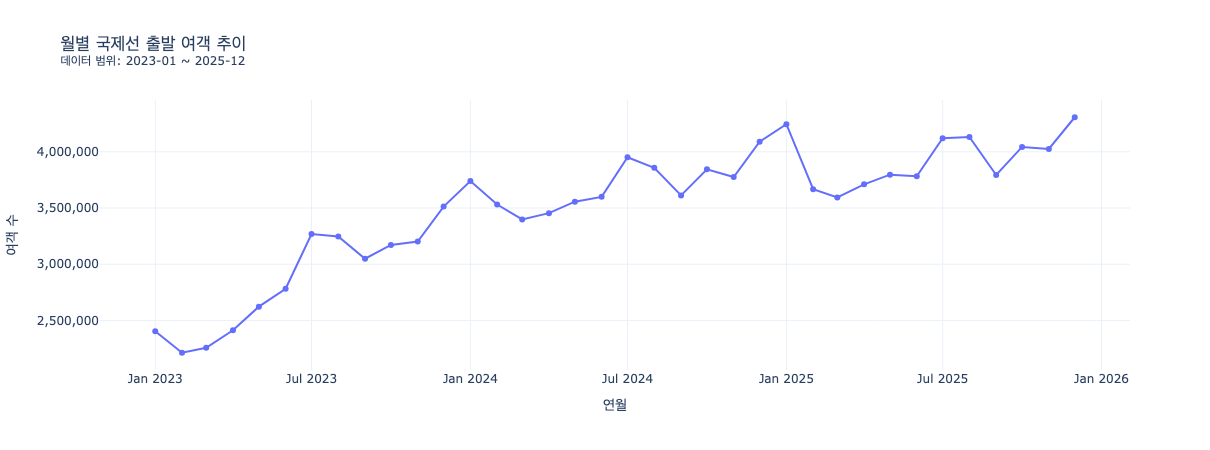

In [11]:
# 차트: 2023~2025년 월별 국제선 출발 여객 추이를 확인한다.
demand_chart = monthly_demand_trend_df.copy()
demand_chart['기준월'] = pd.to_datetime(demand_chart['연월'], format='%Y%m')

fig = px.line(
    demand_chart,
    x='기준월',
    y='여객 수',
    markers=True,
    title=chart_title('월별 국제선 출발 여객 추이', demand_chart['연월']),
    labels={'기준월': '연월', '여객 수': '여객 수'},
    template=PLOTLY_TEMPLATE,
)
fig.update_yaxes(tickformat=',')
fig.update_layout(height=450, showlegend=False)
fig.show(config={'displaylogo': False})


In [12]:
# 연도별 여객·운항 변화를 확인한다.
display(query('yearly_demand_summary'))

,연도,여객 수,운항편 수,편당 여객 수,여객 전년 대비 증감률,운항 전년 대비 증감률
0,2023,34141927.0,205754.0,165.94,NaN,NaN
1,2024,44410715.0,259614.0,171.06,0.3008,0.2618
2,2025,47221285.0,274630.0,171.95,0.0633,0.0578


In [13]:
# 같은 달의 3개 연도 분포로 계절성 후보를 확인한다.
seasonal_demand_profile_df = query('seasonal_demand_profile')
display(seasonal_demand_profile_df)


,월,관측 연도 수,평균 여객 수,최소 여객 수,최대 여객 수,평균 여객 계절 지수,평균 운항편 수,최소 운항편 수,최대 운항편 수,평균 운항 계절 지수
0,01,3,3462840.0,2403433.0,4245703.0,0.9780,19518.0,13632.0,23457.0,0.9374
1,02,3,3136991.0,2212589.0,3667585.0,0.8879,17992.0,12937.0,20844.0,0.8663
2,03,3,3082851.0,2256529.0,3593518.0,0.8749,19255.0,14407.0,22292.0,0.9294
3,04,3,3192625.0,2412373.0,3711069.0,0.9081,18926.0,15231.0,21336.0,0.9183
4,05,3,3325333.0,2622755.0,3796858.0,0.9492,20115.0,16781.0,22269.0,0.9787
5,06,3,3388055.0,2782311.0,3782537.0,0.9706,19895.0,16757.0,21972.0,0.9687
6,07,3,3780603.0,3269172.0,4121097.0,1.0880,21718.0,18718.0,23917.0,1.0592
7,08,3,3745637.0,3247603.0,4131767.0,1.0779,22172.0,19138.0,24457.0,1.0815
8,09,3,3485201.0,3048940.0,3794162.0,1.0040,20968.0,18503.0,22472.0,1.0249
9,10,3,3686741.0,3171814.0,4043529.0,1.0604,22129.0,19565.0,24194.0,1.0814


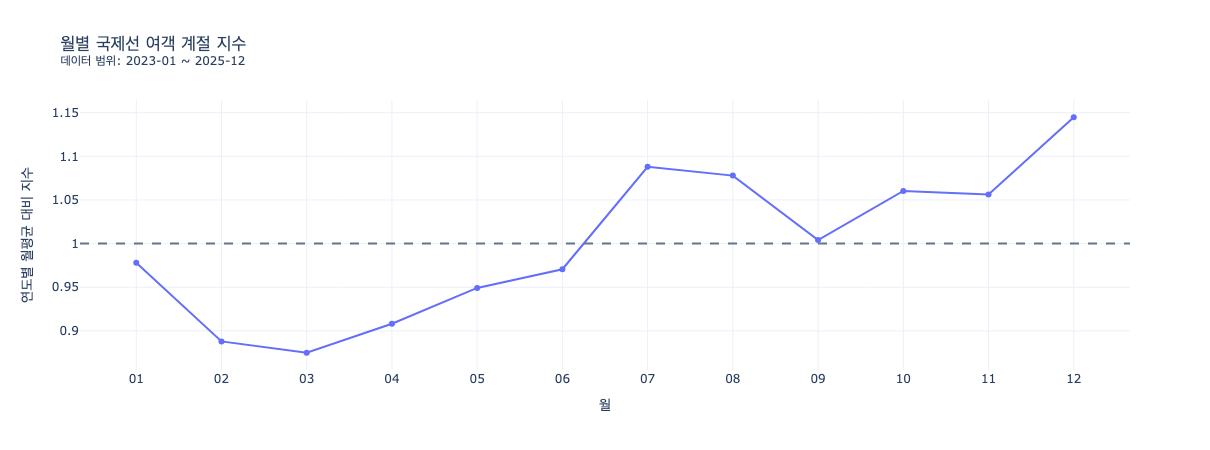

In [14]:
# 차트: 각 달이 같은 연도의 월평균보다 높거나 낮은 정도를 비교한다.
fig = px.line(
    seasonal_demand_profile_df,
    x='월',
    y='평균 여객 계절 지수',
    markers=True,
    title=chart_title('월별 국제선 여객 계절 지수', monthly_demand_trend_df['연월']),
    labels={'평균 여객 계절 지수': '연도별 월평균 대비 지수'},
    template=PLOTLY_TEMPLATE,
)
fig.add_hline(y=1, line_dash='dash', line_color='#64748B')
fig.update_xaxes(dtick=1)
fig.update_layout(height=450, showlegend=False)
fig.show(config={'displaylogo': False})


In [15]:
# 출발공항별 수요 집중도를 확인한다.
display(query('airport_demand_distribution'))

,출발공항 원문,여객 수,관측 월 수,여객 비중
0,인천(ICN),99501308.0,36,0.7911
1,김해(PUS),12910339.0,36,0.1026
2,김포(GMP),5772279.0,36,0.0459
3,제주(CJU),3296225.0,36,0.0262
4,대구(TAE),1999501.0,36,0.0159
5,청주(CJJ),1956303.0,36,0.0156
6,무안(MWX),295884.0,24,0.0024
7,양양(YNY),41883.0,24,0.0003
8,울산(USN),205.0,1,0.0000


In [16]:
# 국가별 수요 집중도를 확인한다.
display(query('country_demand_distribution'))

,지역 원문,국가 원문,여객 수,관측 월 수,여객 비중
0,일본,일본,35894431.0,36,0.2854
1,중국,중국,18580666.0,36,0.1477
2,아시아,베트남,14861590.0,36,0.1182
3,미주,미국,8161919.0,36,0.0649
4,아시아,대만,7120658.0,36,0.0566
5,아시아,태국,6511002.0,36,0.0518
6,아시아,필리핀,6496383.0,36,0.0517
7,아시아,홍콩,3992162.0,36,0.0317
8,아시아,싱가포르,3389990.0,36,0.0270
9,아시아,말레이시아,1918449.0,36,0.0153


In [17]:
# 목적지별 상위 수요를 확인한다.
display(query('destination_demand_distribution'))

,목적지 공항 원문,여객 수,운항편 수,관측 월 수,여객 비중,편당 여객 수
0,간사이(KIX),10074906.0,54720.0,36,0.0801,184.12
1,도쿄 나리타(NRT),8028573.0,45223.0,36,0.0638,177.53
2,후쿠오카(FUK),6836989.0,36207.0,36,0.0544,188.83
3,타이페이(TPE),5664867.0,27379.0,36,0.0450,206.91
4,방콕(BKK),5019984.0,21993.0,36,0.0399,228.25
5,다낭(DAD),4427644.0,24412.0,36,0.0352,181.37
6,푸동(PVG),4010086.0,28177.0,36,0.0319,142.32
7,홍콩(HKG),3992162.0,24859.0,36,0.0317,160.59
8,싱가폴(SIN),3389990.0,15171.0,36,0.0270,223.45
9,나트랑캄란(CXR),3299639.0,18337.0,36,0.0262,179.94


In [18]:
# 출발공항·목적지 노선별 상위 수요를 확인한다.
display(query('route_demand_distribution'))

,출발공항 원문,목적지 공항 원문,여객 수,운항편 수,관측 월 수,여객 비중,편당 여객 수
0,인천(ICN),도쿄 나리타(NRT),6519958.0,35765.0,36,0.0518,182.30
1,인천(ICN),간사이(KIX),6339941.0,33820.0,36,0.0504,187.46
2,인천(ICN),후쿠오카(FUK),4808196.0,24967.0,36,0.0382,192.58
3,인천(ICN),방콕(BKK),4166800.0,17065.0,36,0.0331,244.17
4,인천(ICN),홍콩(HKG),3593391.0,22455.0,36,0.0286,160.03
5,인천(ICN),타이페이(TPE),3377975.0,12784.0,36,0.0269,264.23
6,인천(ICN),다낭(DAD),3076327.0,16290.0,36,0.0245,188.85
7,인천(ICN),싱가폴(SIN),3023464.0,12771.0,36,0.0240,236.74
8,김포(GMP),도쿄 하네다(HND),2762661.0,12945.0,36,0.0220,213.42
9,인천(ICN),마닐라(MNL),2519992.0,12391.0,36,0.0200,203.37


In [19]:
# 항공사별 여객·운항 분포를 확인한다.
display(query('airline_demand_distribution'))

,항공사 원문,여객 수,운항편 수,관측 월 수,여객 비중,편당 여객 수
0,대한항공(KAL),25357276.0,144219.0,36,0.2016,175.82
1,아시아나항공(AAR),16612376.0,83518.0,36,0.1321,198.91
2,제주항공(JJA),11848138.0,74514.0,36,0.0942,159.01
3,티웨이항공(TWB),9539155.0,52293.0,36,0.0758,182.42
4,진에어(JNA),9097771.0,46599.0,36,0.0723,195.24
5,에어부산(ABL),6167055.0,32972.0,36,0.0490,187.04
6,비엣젯항공(VJC),3998190.0,22734.0,36,0.0318,175.87
7,중국동방항공(CES),2978724.0,21387.0,36,0.0237,139.28
8,이스타항공(ESR),2648605.0,16094.0,28,0.0211,164.57
9,에어서울(ASV),2530050.0,13603.0,36,0.0201,185.99


### 수요 관찰

- 국제선 출발 여객은 2023년 3,414만 명, 2024년 4,441만 명, 2025년 4,722만 명으로 집계됐다. 전년 대비 증가는 각각 30.08%, 6.33%다.
- 연도별 규모 차이를 보정한 계절 지수는 12월이 1.1448로 가장 높고 7·8월도 1을 웃돈다. 2·3월은 상대적으로 낮다.
- 인천공항은 전체 국제선 출발 여객의 79.11%를 차지하며, 국가별로는 일본·중국·베트남 순으로 비중이 크다.
- 관측 기간이 3개 연도뿐이고 2023년 회복 효과가 있으므로 계절성과 장기 성장성을 동일하게 해석하지 않는다.

## 3. 상태값·시간차와 지연 정의 선택지

In [20]:
# 여객편 상태와 보정 전 실제·계획 시간차를 확인한다.
display(query('status_time_relationship'))

,출발공항 원문,상태 원문,여객편 수,시간 계산 가능 편 수,시간 계산 가능 비율,최소 원시 시간차(분),최대 원시 시간차(분),평균 원시 시간차(분),음수 시간차 편 수,0분 편 수,1~14분 편 수,15~29분 편 수,30분 이상 편 수
0,김포,출발,28477,28375.0,0.9964,-40.0,546.0,15.27,248.0,123.0,14256.0,12636.0,1112.0
1,김포,지연,2232,2229.0,0.9987,-47.0,624.0,58.32,1.0,0.0,5.0,73.0,2150.0
2,김포,(NULL),155,0.0,0.0000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,김포,취소,27,1.0,0.0370,28.0,28.0,28.00,0.0,0.0,0.0,1.0,0.0
4,김포,회항,8,8.0,1.0000,9.0,78.0,25.75,0.0,0.0,3.0,3.0,2.0
5,인천,출발,347917,346814.0,0.9968,-1104.0,780.0,21.68,5223.0,1172.0,66499.0,206460.0,67460.0
6,인천,지연,153285,152716.0,0.9963,-1222.0,1331.0,62.17,21.0,7.0,49.0,843.0,151796.0
7,인천,(NULL),2567,0.0,0.0000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
8,인천,취소,693,3.0,0.0043,-81.0,121.0,53.00,1.0,0.0,0.0,0.0,2.0
9,인천,회항,81,81.0,1.0000,-4.0,384.0,52.37,1.0,0.0,5.0,28.0,47.0


In [21]:
# 계획·예상·실제 시각 간 보정 전 관계를 확인한다.
display(query('scheduled_estimated_actual_relationship'))

,출발공항 원문,상태 원문,여객편 수,계획·예상 계산 가능 편 수,평균 예상-계획 시간차(분),예상시각이 계획보다 이른 편 수,예상·실제 계산 가능 편 수,평균 실제-예상 시간차(분),실제시각이 예상보다 이른 편 수
0,김포,출발,28477,28401.0,0.16,11.0,28375.0,15.11,257.0
1,김포,지연,2232,2230.0,25.12,2.0,2229.0,33.19,23.0
2,김포,(NULL),155,28.0,0.00,0.0,0.0,NaN,0.0
3,김포,취소,27,14.0,66.07,0.0,0.0,NaN,0.0
4,김포,회항,8,8.0,68.75,0.0,8.0,-43.00,1.0
5,인천,출발,347917,346808.0,9.47,1135.0,346808.0,12.21,6276.0
6,인천,지연,153285,153110.0,25.08,197.0,152733.0,37.20,659.0
7,인천,(NULL),2567,1267.0,-3.67,23.0,0.0,NaN,0.0
8,인천,취소,693,226.0,141.57,7.0,1.0,-1351.00,1.0
9,인천,회항,81,72.0,34.82,0.0,72.0,15.57,4.0


In [22]:
# 분모 후보별 포함 행 수를 비교한다.
display(query('denominator_candidate_profile'))

,출발공항 원문,여객편 수,상태상 운항 편 수,시간 계산 가능 편 수,상태상 운항·시간 계산 가능 편 수,취소 외 편 수,취소 편 수,회항 편 수,상태 미상 편 수
0,김포,30899,30709.0,30613.0,30604.0,30872.0,27.0,8.0,155.0
1,인천,504543,501202.0,499614.0,499530.0,503850.0,693.0,81.0,2567.0


In [23]:
# 임계값별 시간 기준과 원문 지연 상태의 차이를 비교한다.
delay_threshold_sensitivity_df = query('delay_threshold_sensitivity')
display(delay_threshold_sensitivity_df)


,출발공항 원문,임계값(분),분모 후보 편 수,상태 지연 편 수,임계값 지연 편 수,임계값 지연 비율,두 기준 모두 지연 편 수,상태만 지연 편 수,임계값만 지연 편 수
0,김포,0,30604,2229.0,30355.0,0.9919,2228.0,1.0,28127.0
1,김포,5,30604,2229.0,29054.0,0.9494,2227.0,2.0,26827.0
2,김포,10,30604,2229.0,24367.0,0.7962,2227.0,2.0,22140.0
3,김포,15,30604,2229.0,15971.0,0.5219,2223.0,6.0,13748.0
4,김포,20,30604,2229.0,9011.0,0.2944,2221.0,8.0,6790.0
5,김포,30,30604,2229.0,3262.0,0.1066,2150.0,79.0,1112.0
6,김포,60,30604,2229.0,696.0,0.0227,586.0,1643.0,110.0
7,인천,0,499530,152716.0,494286.0,0.9895,152695.0,21.0,341591.0
8,인천,5,499530,152716.0,485991.0,0.9729,152673.0,43.0,333318.0
9,인천,10,499530,152716.0,466917.0,0.9347,152653.0,63.0,314264.0


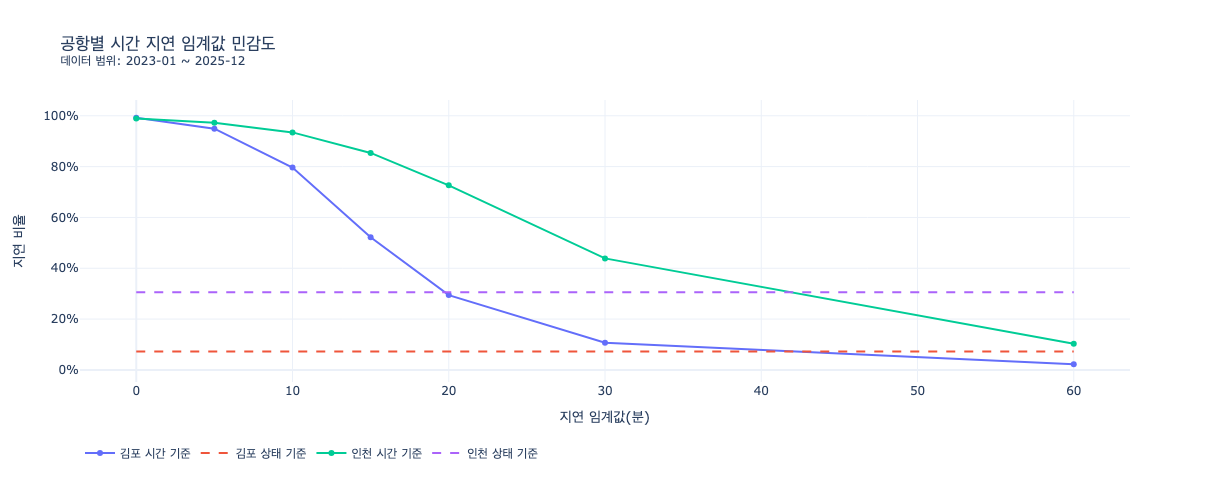

In [24]:
# 차트: 시간 지연 임계값 변화에 따른 지연 비율 민감도를 비교한다.
fig = go.Figure()
for airport, group in delay_threshold_sensitivity_df.groupby('출발공항 원문'):
    fig.add_trace(go.Scatter(
        x=group['임계값(분)'],
        y=group['임계값 지연 비율'],
        mode='lines+markers',
        name=f'{airport} 시간 기준',
    ))
    status_rate = group['상태 지연 편 수'].iloc[0] / group['분모 후보 편 수'].iloc[0]
    fig.add_trace(go.Scatter(
        x=[group['임계값(분)'].min(), group['임계값(분)'].max()],
        y=[status_rate, status_rate],
        mode='lines',
        line={'dash': 'dash'},
        name=f'{airport} 상태 기준',
    ))

fig.update_layout(
    title=chart_title('공항별 시간 지연 임계값 민감도', EDA_PERIODS),
    xaxis_title='지연 임계값(분)',
    yaxis_title='지연 비율',
    yaxis_tickformat='.0%',
    template=PLOTLY_TEMPLATE,
    height=480,
    legend={'orientation': 'h', 'y': -0.2},
)
fig.show(config={'displaylogo': False})


In [25]:
# 15분 시간 지연 비율이 상태 지연 비율보다 크게 높은 원인을 점검한다.
# 항공사가 정시로 신고한 편만 남겨 실제-계획 시간차를 본다.
display(query('departure_time_basis_check'))


,출발공항 원문,정시 신고 편 수,실제-계획 중앙 시간차(분),실제-계획 평균 시간차(분),15분 이상 시간차 비율
0,김포,28178,14.0,15.1,0.4821
1,인천,339907,22.0,21.8,0.7945


#### 시간차 기준 점검 — 두 지연 비율의 차이는 어디서 오나

항공사가 정시로 신고한 편(상태 `출발`이고 예상시각 = 계획시각)만 남겨도 **실제출발 − 계획출발 시간차 중앙값이 김포 14분, 인천 22분**이고, 15분 이상인 비율은 김포 48.21%·인천 79.45%다. 지연으로 표기되지 않은 편에서도 시간차가 이만큼 남는다는 뜻이다.

두 공항의 8분 격차는 정시성 차이보다 지상 이동(taxi-out) 시간 차이의 크기에 가깝다. 즉 `actual_departure_time_raw`가 게이트 출발(푸시백)이 아니라 그보다 늦은 시점에 가깝게 기록됐을 가능성이 있으며, 계획시각과 직접 빼면 구조적으로 과대 집계된다.

원본에 시각의 기준이 명시돼 있지 않아 확정할 수는 없다. 따라서 15분 시간 지연 비율을 국제 표준 정시성 지표로 해석하지 않고, 상태 지연 비율과 **정의가 다른 별개 지표**로 병행 제공한다.


In [26]:
# 음수 시간차의 크기를 확인한다.
display(query('midnight_negative_gap_profile'))

,출발공항 원문,상태 원문,음수 시간차 구간,출발편 수,최소 원시 시간차(분),최대 원시 시간차(분),최소 계획 시,최대 계획 시
0,김포,지연,minus_60_to_minus_1,1,-47,-47,17,17
1,김포,출발,minus_60_to_minus_1,248,-40,-1,7,22
2,인천,지연,at_or_below_minus_720,1,-1222,-1222,22,22
3,인천,지연,minus_719_to_minus_61,1,-136,-136,23,23
4,인천,지연,minus_60_to_minus_1,19,-14,-1,0,8
5,인천,출발,at_or_below_minus_720,1,-1104,-1104,18,18
6,인천,출발,minus_719_to_minus_61,6,-520,-112,8,8
7,인천,출발,minus_60_to_minus_1,5216,-60,-1,0,23
8,인천,취소,minus_719_to_minus_61,1,-81,-81,2,2
9,인천,회항,minus_60_to_minus_1,1,-4,-4,1,1


In [27]:
# 자정 보정 후보별 민감도를 확인한다.
display(query('midnight_adjustment_sensitivity'))

,출발공항 원문,보정 후보,후보 편 수,보정 적용 편 수,보정 후 음수 편 수,보정 후 평균 시간차(분),15분 이상 편 수,30분 이상 편 수
0,김포,raw_no_adjustment,30604,0.0,249.0,18.41,15971.0,3262.0
1,김포,add_1440_if_gap_le_minus_720,30604,0.0,249.0,18.41,15971.0,3262.0
2,김포,add_1440_to_all_negative,30604,249.0,0.0,30.12,16220.0,3511.0
3,인천,raw_no_adjustment,499530,0.0,5244.0,34.06,426559.0,219256.0
4,인천,add_1440_if_gap_le_minus_720,499530,2.0,5242.0,34.06,426561.0,219258.0
5,인천,add_1440_to_all_negative,499530,5244.0,0.0,49.17,431803.0,224500.0


### 시간·지연 해석

- 아래 결과는 국내선·미확정 여객편을 제외한 국제선 여객편 범위이며, 원시 시간차(`raw_gap_minutes`)와 예상-계획 시간차(`est_gap_minutes`)는 날짜 보정 전 값이다.
- 상태상 운항이면서 시간 계산이 가능한 편을 공통 분모로 비교하면 상태값 기준 지연 비율은 김포 7.28%, 인천 30.57%다. 같은 분모의 15분 이상 시간차 비율은 김포 52.19%, 인천 85.39%로 훨씬 높다.
- 두 기준의 차이가 매우 크므로 시간차 기준이 원본 상태값을 그대로 대체한다고 보기 어렵다. 04에서는 운영상 `지연` 상태 비율과 프로젝트 정의인 15분 출발 지연 비율을 별도 지표로 병행한다.
- 항공사가 정시로 신고한 편만 봐도 실제-계획 시간차 중앙값이 김포 14분, 인천 22분이다. 두 지표의 차이는 정시성 차이라기보다 계획시각과 실제출발시각의 기준 차이에서 비롯됐을 가능성이 크므로, 15분 지연 비율의 절대 수준을 다른 공항·국가 통계와 직접 비교하지 않는다.
- 상태상 운항·시간 계산 가능 범위의 음수 시간차는 김포 249건, 인천 5,244건이다. 이 중 `-720분 이하`의 큰 음수는 인천 2건뿐이다.
- 모든 음수에 1,440분을 더하면 실제 조기 출발까지 다음 날 출발로 바꿀 수 있다. 자정 보정은 원시 시간차(`raw_gap_minutes`)가 -720분 이하인 명확한 후보에만 1,440분을 더하는 보수적 방식을 적용한다.

## 4. 지연사유 사용 가능성

In [28]:
# 상태별 지연사유 입력률을 확인한다.
display(query('delay_reason_coverage'))

,출발공항 원문,상태 원문,여객편 수,사유 입력 편 수,사유 입력률
0,김포,출발,28477,0.0,0.0000
1,김포,지연,2232,2099.0,0.9404
2,김포,(NULL),155,0.0,0.0000
3,김포,취소,27,27.0,1.0000
4,김포,회항,8,7.0,0.8750
5,인천,출발,347917,0.0,0.0000
6,인천,지연,153285,148765.0,0.9705
7,인천,(NULL),2567,132.0,0.0514
8,인천,취소,693,693.0,1.0000
9,인천,회항,81,79.0,0.9753


In [29]:
# 표준 지연사유 분포를 확인한다.
delay_reason_distribution_df = query('delay_reason_distribution')
display(delay_reason_distribution_df)


,지연사유 표준값,운항결과 사유 여부,지연사유 원문값,사유 편 수,지연 상태 편 수,출발 상태 편 수,취소 상태 편 수,회항 상태 편 수,상태 미상 편 수
0,항공기 연결에 의한 지연,0,연결-항공기 | 항공기 연결에 의한 지연,55397,55256.0,0.0,56.0,0.0,85.0
1,공항 및 출입국 절차에 의한 지연,0,공항 및 출입국 절차에 의한 지연,37936,37904.0,0.0,18.0,0.0,14.0
2,항공교통흐름에 의한 지연,0,항공교통흐름에 의한 지연,34124,34109.0,0.0,7.0,0.0,8.0
3,여객 및 화물처리에 의한 지연,0,여객 및 화물처리에 의한 지연,8853,8848.0,0.0,3.0,0.0,2.0
4,항공기 정비에 의한 지연,0,항공기 정비에 의한 지연,5632,5515.0,0.0,103.0,0.0,14.0
5,기상에 의한 지연,0,기상에 의한 지연,3060,2680.0,0.0,377.0,0.0,3.0
6,기타 원인에 의한 지연,0,기타 원인에 의한 지연,2708,2586.0,0.0,121.0,0.0,1.0
7,운항 기준 및 승무원 관련 지연,0,운항 기준 및 승무원 관련 지연,2143,2131.0,0.0,11.0,0.0,1.0
8,지상조업 관련 지연,0,지상조업 관련 지연,1675,1671.0,0.0,1.0,0.0,3.0
9,(표준 사유 없음),1,회항,195,89.0,0.0,19.0,86.0,1.0


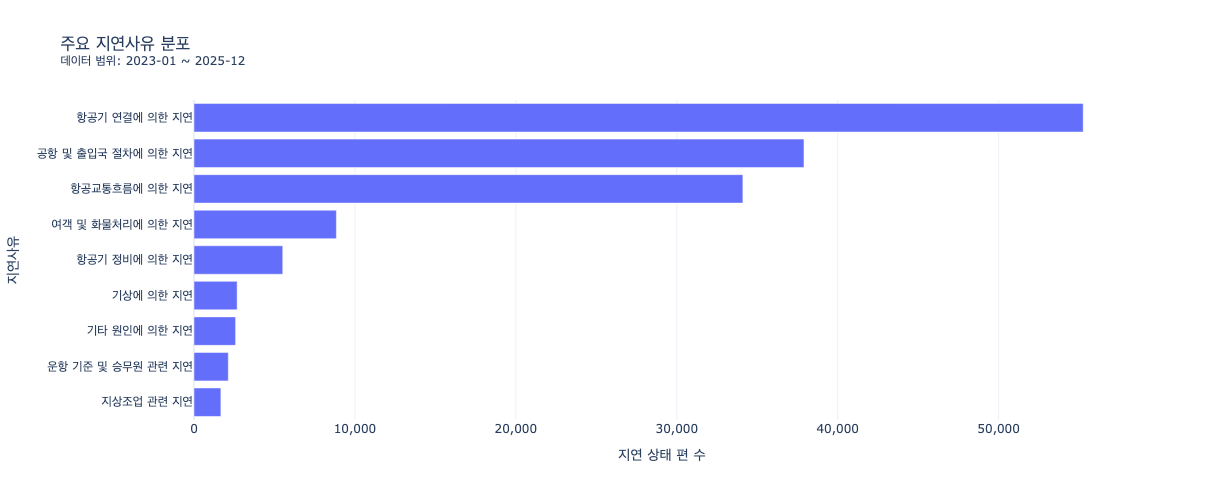

In [30]:
# 차트: 운항 결과인 회항을 제외하고 지연 상태에서 많이 입력된 사유를 비교한다.
reason_chart = (
    delay_reason_distribution_df[
        (delay_reason_distribution_df['운항결과 사유 여부'] == 0)
        & (delay_reason_distribution_df['지연 상태 편 수'] > 0)
    ]
    .nlargest(9, '지연 상태 편 수')
    .sort_values('지연 상태 편 수')
)

fig = px.bar(
    reason_chart,
    x='지연 상태 편 수',
    y='지연사유 표준값',
    orientation='h',
    title=chart_title('주요 지연사유 분포', EDA_PERIODS),
    labels={'지연사유 표준값': '지연사유'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_layout(height=500, showlegend=False)
fig.show(config={'displaylogo': False})


In [31]:
# 상태 회항과 지연원인 회항이 같은 사건을 나타내는지 교차 확인한다.
display(query('diversion_status_reason_crosscheck'))

,출발공항 원문,상태 원문,지연사유 원문,출발편 수
0,인천,지연,회항,87
1,인천,회항,회항,79
2,인천,취소,회항,19
3,김포,회항,회항,7
4,김포,지연,회항,2
5,인천,회항,(NULL),2
6,김포,회항,(NULL),1
7,인천,(NULL),회항,1


### 지연사유 관찰

- 국제선 여객편 중 `지연` 상태의 사유 입력률은 김포 94.04%, 인천 97.05%로 지연사유 분포 분석에 사용할 수 있는 수준이다. 04 집계에서는 일부 결측을 `미입력` 범주로 보존한다.
- 사유 원문이 `회항`인 195건은 지연 89건, 취소 19건, 회항 86건, 상태 미상 1건에 걸쳐 있다. 특정 지연 원인이라기보다 운항 결과 표기로 보는 현재 전처리 구분이 타당하다.
- 04의 지연사유 분포에서는 `회항`을 원인에서 제외하고 회항률·회항 교차검증으로 별도 관리한다.

## 5. 04 적용 방향

| 항목 | 선택한 방향 | 남은 확인 |
|---|---|---|
| 분석 범위 | 여객편·국제선 여부가 모두 참(`is_passenger = TRUE AND is_international = TRUE`) | 미확정 목적지 14개 조합의 외부 참조 확인 |
| 지연 정의 | 원본 `지연` 상태와 15분 이상 출발 지연을 별도 지표로 병행 | 두 지표의 명칭을 명확히 구분 |
| 지연률 분모 | 상태 지연률은 `출발·지연`, 시간차 지연률은 `출발·지연`이면서 시간 계산 가능 | 없음 |
| 자정 보정 | 원시 시간차(`raw_gap_minutes`)가 -720분 이하인 후보에만 1,440분 추가 | 보정 후 이상치 재확인 |
| 취소·회항 | 지연률 분모에서 제외하고 취소율·회항률로 별도 계산 | 없음 |
| 지연사유의 회항 | 지연 원인에서 제외하고 운항 결과로 별도 관리 | 없음 |

04 구현 전 미확정 목적지의 추가 확인을 마치고, 위 방향을 비즈니스 지표 뷰에 일관되게 반영한다.

## 6. 주요 발견과 결론

- 국제선 출발 여객은 2023년 3,414만 명에서 2025년 4,722만 명으로 증가했으며, 12월과 7·8월의 계절 지수가 높다. 인천공항이 전체 수요의 79.11%를 차지하고 일본·중국·베트남 순으로 수요가 크다.
- 출발 로그의 국제선 여객편은 535,442건이다. 미확정은 전체 여객편의 0.17%이고 참조 충돌은 없어 기본 국제선 범위는 안정적이지만, 미확정 목적지 14개 조합은 04 이전에 추가 확인한다.
- 상태값 기준 지연과 15분 시간차 기준 지연의 차이가 커서 하나의 지연률로 합치지 않는다. 04에서는 운영상 지연률과 15분 출발 지연률을 함께 제공한다.
- 시간값의 음수 대부분은 `-720분`보다 크므로 일괄 자정 보정은 부적절하다. 명확한 자정 후보만 보정하고 나머지 음수는 조기 출발 또는 데이터 품질 관찰값으로 유지한다.
- 지연사유 입력률은 지연편의 94% 이상으로 분석 가능하다. 취소와 회항은 지연률에서 분리하고, 사유값 `회항`도 지연 원인이 아닌 운항 결과로 관리한다.
- 03은 수요·운항 안정성의 주요 패턴과 규칙 선택 근거를 제시했다. 04는 위에서 선택한 범위·분모·보정 규칙을 적용해 월별 수요, 지연률, 취소율, 회항률과 지연사유 지표를 구현한다.